In [ ]:
pip install pytorch-tabnet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 3.1 MB/s eta 0:00:00


In [ ]:
from pytorch_tabnet.tab_model import TabNetClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import torch

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score

In [ ]:
# Imports
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from pytorch_tabnet.tab_model import TabNetClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import torch

# Setting seeds for reproducibility
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)

# Load Dataset
df = pd.read_excel("New Final DataSet Without Sulphur.xlsx", engine='openpyxl')

# Select only numerical columns for scaling (excluding 'S')
columns_to_scale = ['N', 'P', 'K', 'pH', 'Temp(°C)', 'Humidity(%)', 'Moisture(%)', 'Rainfall(cm)']

# Scale the selected columns
scaler = MinMaxScaler()
df_scaled = df.copy()
df_scaled[columns_to_scale] = scaler.fit_transform(df[columns_to_scale])

# Encode the target variable
label_encoder = LabelEncoder()
df_scaled['label_encoded'] = label_encoder.fit_transform(df_scaled['Crop'])
df_scaled.drop(columns=['Crop'], inplace=True)

# Remove 'S' from the features
df_scaled.drop(columns=['S'], inplace=True, errors='ignore')

# Split into features (X) and target (y)
X = df_scaled.drop(columns=['label_encoded']).values
y = df_scaled['label_encoded'].values

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=seed)

# TabNet Model
tabnet_model = TabNetClassifier(
    n_d=64, n_a=64, n_steps=5, gamma=1.5, n_independent=2, n_shared=2,
    optimizer_fn=torch.optim.Adam, optimizer_params=dict(lr=2e-2),
    mask_type='entmax', verbose=1
)

# Training the TabNet model
tabnet_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    eval_name=['train', 'test'],
    eval_metric=['accuracy'],
    max_epochs=100,
    patience=10,
    batch_size=256,
    virtual_batch_size=128,
    num_workers=0
)

# Predictions on training and testing data
y_train_pred = tabnet_model.predict(X_train)
y_test_pred = tabnet_model.predict(X_test)

# Calculate training and testing accuracy
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

# Calculate precision, recall, and F1 score for test set
test_precision = precision_score(y_test, y_test_pred, average='weighted')
test_recall = recall_score(y_test, y_test_pred, average='weighted')
test_f1 = f1_score(y_test, y_test_pred, average='weighted')

# Print results
print(f"Train Accuracy: {train_accuracy * 100:.2f}%")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Precision: {test_precision:.2f}")
print(f"Test Recall: {test_recall:.2f}")
print(f"Test F1 Score: {test_f1:.2f}")

# Classification report for test set
print("Classification Report (Test Set):")
print(classification_report(y_test, y_test_pred))

# Confusion matrix for test set
print("Confusion Matrix (Test Set):")
print(confusion_matrix(y_test, y_test_pred))


/usr/local/lib/python3.10/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 2.49403 | train_accuracy: 0.04924 | test_accuracy: 0.05152 |  0:00:01s
epoch 1  | loss: 0.83515 | train_accuracy: 0.0875  | test_accuracy: 0.08333 |  0:00:02s
epoch 2  | loss: 0.49794 | train_accuracy: 0.11629 | test_accuracy: 0.12273 |  0:00:03s
epoch 3  | loss: 0.40922 | train_accuracy: 0.10909 | test_accuracy: 0.11061 |  0:00:04s
epoch 4  | loss: 0.32332 | train_accuracy: 0.08712 | test_accuracy: 0.09091 |  0:00:06s
epoch 5  | loss: 0.29879 | train_accuracy: 0.12045 | test_accuracy: 0.11667 |  0:00:07s
epoch 6  | loss: 0.25359 | train_accuracy: 0.19621 | test_accuracy: 0.19848 |  0:00:08s
epoch 7  | loss: 0.25762 | train_accuracy: 0.15    | test_accuracy: 0.15303 |  0:00:11s
epoch 8  | loss: 0.2563  | train_accuracy: 0.15568 | test_accuracy: 0.15909 |  0:00:15s
epoch 9  | loss: 0.24433 | train_accuracy: 0.175   | test_accuracy: 0.19394 |  0:00:17s
epoch 10 | loss: 0.21503 | train_accuracy: 0.2053  | test_accuracy: 0.21515 |  0:00:18s
epoch 11 | loss: 0.22897 | train

/usr/local/lib/python3.10/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


Train Accuracy: 95.42%
Test Accuracy: 91.97%
Test Precision: 0.93
Test Recall: 0.92
Test F1 Score: 0.92
Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.63      0.80      0.71        30
           1       0.81      0.83      0.82        30
           2       0.70      0.87      0.78        30
           3       0.87      0.67      0.75        30
           4       1.00      1.00      1.00        30
           5       0.97      1.00      0.98        30
           6       0.93      0.93      0.93        30
           7       0.88      0.70      0.78        30
           8       0.91      0.97      0.94        30
           9       0.97      0.93      0.95        30
          10       0.88      0.97      0.92        30
          11       0.96      0.87      0.91        30
          12       1.00      0.97      0.98        30
          13       1.00      1.00      1.00        30
          14       0.90      0.93      0.92        

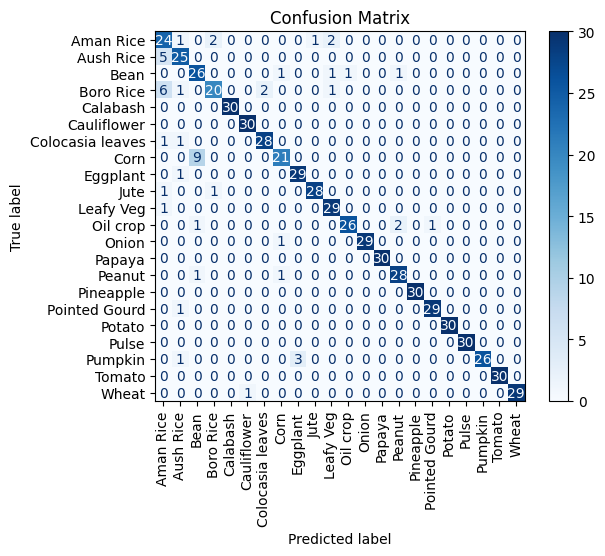

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

# Plot the confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_test_pred,
    display_labels=label_encoder.classes_,
    cmap='Blues',
    xticks_rotation='vertical'
)
plt.title("Confusion Matrix")
plt.savefig('tabnetConfusion.png',transparent=True)  # Save the plot as an image file

plt.show()


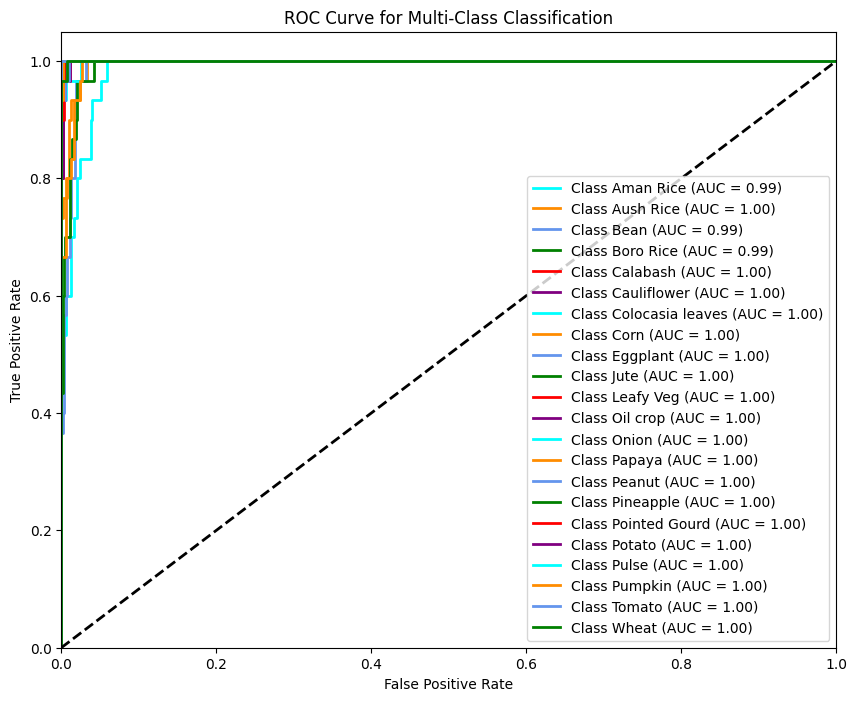

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from itertools import cycle

# Binarize the output for multi-class ROC
y_test_binarized = label_binarize(y_test, classes=np.arange(len(label_encoder.classes_)))
n_classes = y_test_binarized.shape[1]

# Predict probabilities for test set
y_test_pred_proba = tabnet_model.predict_proba(X_test)

# Plotting the ROC curve
plt.figure(figsize=(10, 8))
colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'green', 'red', 'purple'])

for i, color in zip(range(n_classes), colors):
    fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_test_pred_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2, label=f"Class {label_encoder.inverse_transform([i])[0]} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--', lw=2)  # Diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Multi-Class Classification")
plt.legend(loc="lower right")
plt.savefig('tabnetRoc.png',transparent=True)  # Save the plot as an image file
plt.show()



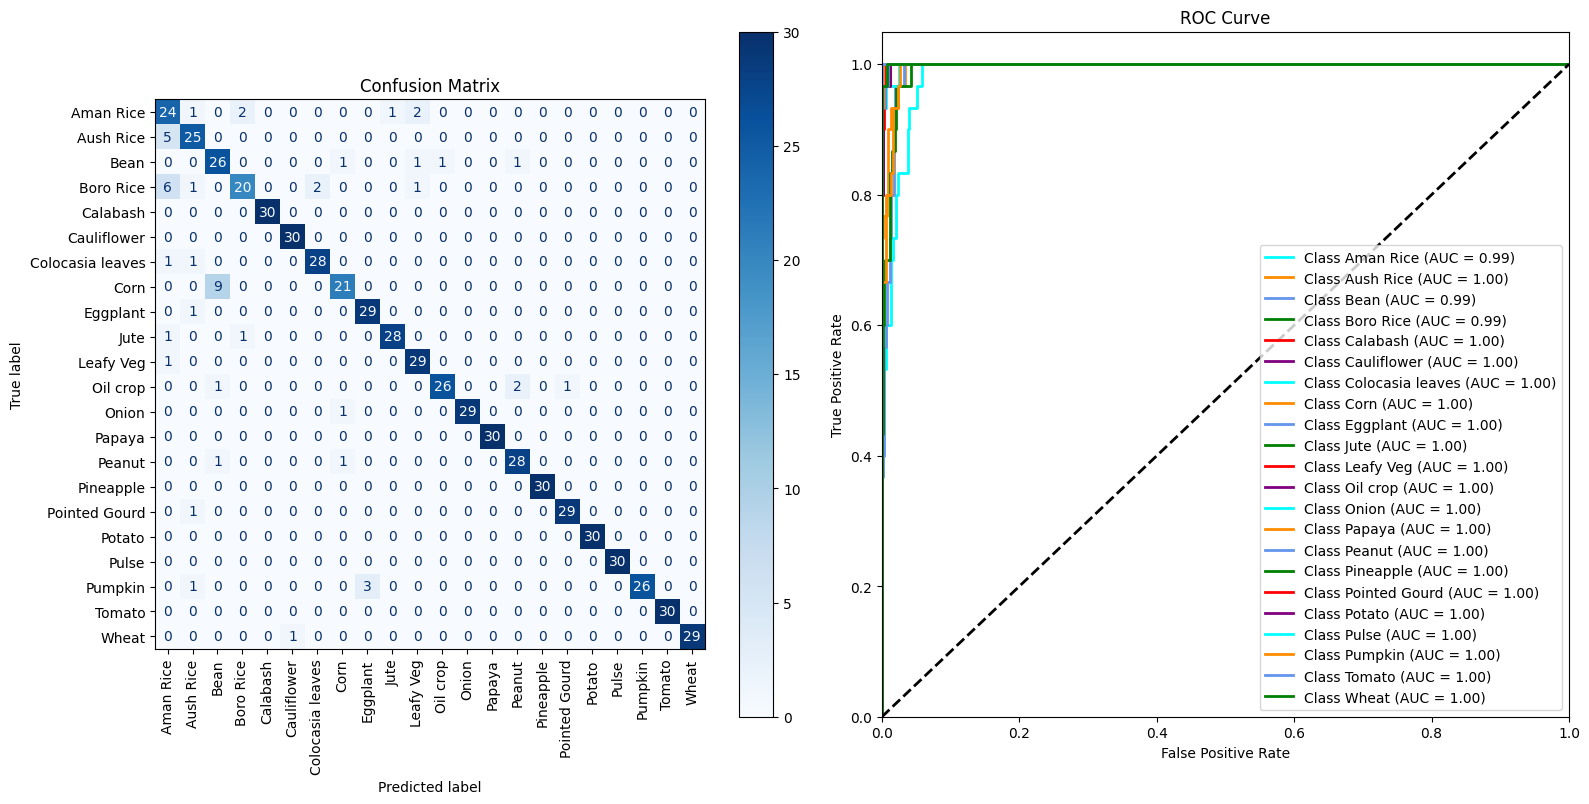

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, roc_curve, auc
from sklearn.preprocessing import label_binarize
from itertools import cycle

# Prepare data for ROC curve
y_test_binarized = label_binarize(y_test, classes=np.arange(len(label_encoder.classes_)))
n_classes = y_test_binarized.shape[1]
y_test_pred_proba = tabnet_model.predict_proba(X_test)

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Plot Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_test_pred,
    display_labels=label_encoder.classes_,
    cmap='Blues',
    xticks_rotation='vertical',
    ax=axes[0]
)
axes[0].set_title("Confusion Matrix")

# Plot ROC Curve
colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'green', 'red', 'purple'])
for i, color in zip(range(n_classes), colors):
    fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_test_pred_proba[:, i])
    roc_auc = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, color=color, lw=2, label=f"Class {label_encoder.inverse_transform([i])[0]} (AUC = {roc_auc:.2f})")

axes[1].plot([0, 1], [0, 1], 'k--', lw=2)  # Diagonal line
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve")
axes[1].legend(loc="lower right")

# Show the plots

plt.tight_layout()
plt.savefig('tabnetRocCon.png',transparent=True)  # Save the plot as an image file
plt.show()


{'loss': [2.4940330266952513, 0.835152518749237, 0.49794442355632784, 0.4092235594987869, 0.3233246773481369, 0.29879420846700666, 0.25359427332878115, 0.2576218664646149, 0.25630253106355666, 0.24433443695306778, 0.21502670794725418, 0.2289739653468132, 0.24182915687561035, 0.18750615492463113, 0.19451119750738144, 0.20655401796102524, 0.24238881468772888, 0.21053722575306894, 0.19418446570634842, 0.18908738642930983, 0.2029578998684883, 0.17067915722727775, 0.1861653208732605, 0.19513370394706725, 0.15865466594696045, 0.16456542015075684, 0.15573953688144684, 0.1596136912703514, 0.1514604516327381, 0.17037272825837135, 0.1659439355134964, 0.17400302290916442, 0.21857489198446273, 0.1827044390141964, 0.154985523596406, 0.14643339291214943, 0.16785422191023827, 0.17371828109025955, 0.16173552945256234, 0.15091635957360267, 0.16520815640687941, 0.18329865857958794, 0.22158602327108384, 0.19590755850076674, 0.23109873831272126, 0.17833204790949822, 0.1614436127245426, 0.1802838586270809,

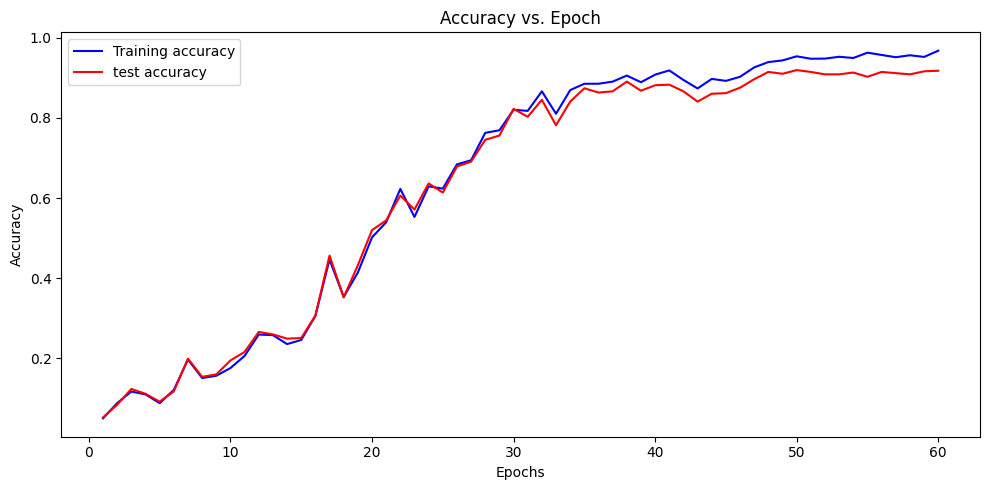

In [ ]:
history = tabnet_model.history
print(history)

# Extract and plot values
train_losses = history['loss']
train_accuracies = history['train_accuracy']
valid_accuracies = history['test_accuracy']

epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs, train_accuracies, 'b-', label='Training accuracy')
plt.plot(epochs, valid_accuracies, 'r-', label='test accuracy')
plt.title('Accuracy vs. Epoch')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.savefig('tabnet.png',transparent=True)  # Save the plot as an image file
plt.show()


Feature Importance:
[0.03168001 0.06628613 0.09815047 0.24570718 0.07242882 0.17258528
 0.17003275 0.14312937]


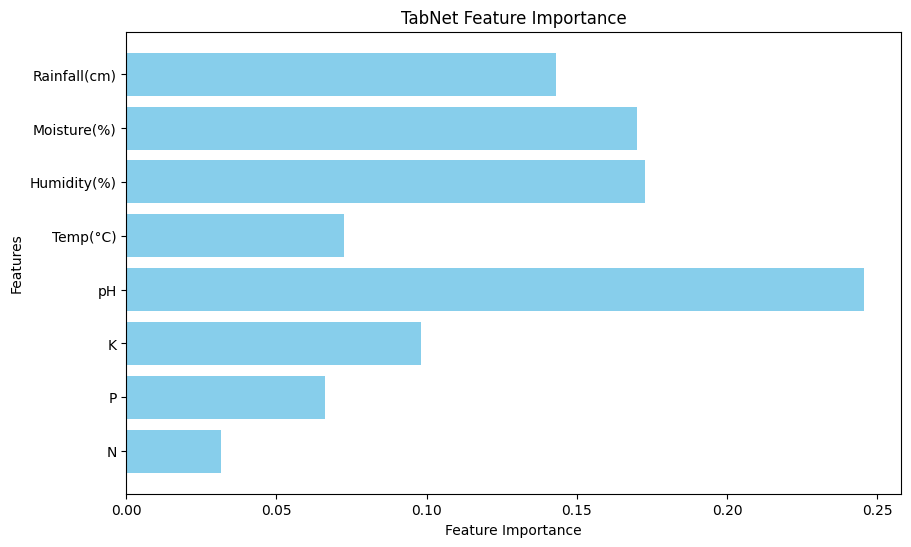

In [ ]:
# Feature Importance
print("Feature Importance:")
print(tabnet_model.feature_importances_)

# Plot Feature Importance
plt.figure(figsize=(10, 6))
plt.barh(columns_to_scale, tabnet_model.feature_importances_, color='skyblue')
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('TabNet Feature Importance')
plt.show()



In [ ]:
# Classification report for test set
print("Classification Report (Test Set):")
print(classification_report(y_test, y_test_pred, digits=3))

Classification Report (Test Set):
              precision    recall  f1-score   support

           0      0.632     0.800     0.706        30
           1      0.806     0.833     0.820        30
           2      0.703     0.867     0.776        30
           3      0.870     0.667     0.755        30
           4      1.000     1.000     1.000        30
           5      0.968     1.000     0.984        30
           6      0.933     0.933     0.933        30
           7      0.875     0.700     0.778        30
           8      0.906     0.967     0.935        30
           9      0.966     0.933     0.949        30
          10      0.879     0.967     0.921        30
          11      0.963     0.867     0.912        30
          12      1.000     0.967     0.983        30
          13      1.000     1.000     1.000        30
          14      0.903     0.933     0.918        30
          15      1.000     1.000     1.000        30
          16      0.967     0.967     0.967    

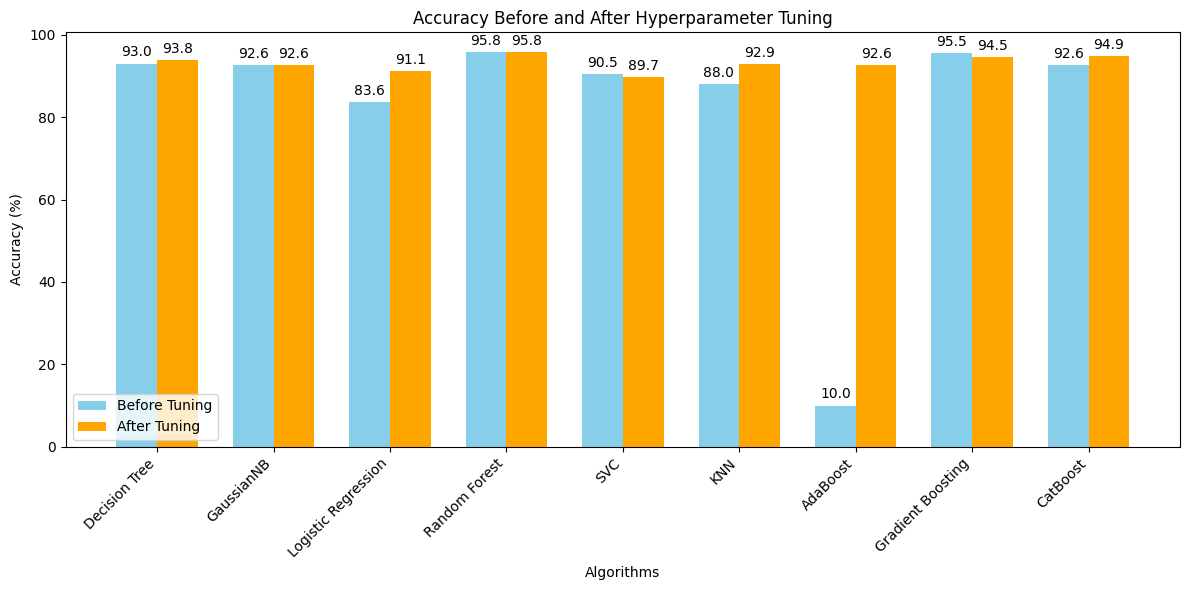

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Data from the table
models = [
    "Decision Tree", "GaussianNB", "Logistic Regression",
    "Random Forest", "SVC", "KNN", "AdaBoost",
    "Gradient Boosting", "CatBoost"
]
accuracy_before = [93.0, 92.6, 83.6, 95.8, 90.5, 88.0, 10.0, 95.5, 92.6]
accuracy_after = [93.8, 92.6, 91.1, 95.8, 89.7, 92.9, 92.6, 94.5, 94.9]

# Bar width and positions
bar_width = 0.35
x = np.arange(len(models))

# Plotting the bar chart
fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - bar_width/2, accuracy_before, bar_width, label="Before Tuning", color="skyblue")
bars2 = ax.bar(x + bar_width/2, accuracy_after, bar_width, label="After Tuning", color="orange")

# Adding labels, title, and legend
ax.set_xlabel("Algorithms")
ax.set_ylabel("Accuracy (%)")
ax.set_title("Accuracy Before and After Hyperparameter Tuning")
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=45, ha="right")
ax.legend()

# Annotating the bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f"{height}",
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # Offset text by 3 points
                    textcoords="offset points",
                    ha='center', va='bottom')

# Show the plot
plt.tight_layout()
plt.savefig('modelchart.png',transparent=True)  # Save the plot as an image file

plt.show()


In [ ]:
import time
import torch
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from pytorch_tabnet.tab_model import TabNetClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

# Setting seeds for reproducibility
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)

# Load Dataset
df = pd.read_excel("New Final DataSet Without Sulphur.xlsx", engine='openpyxl')

# Select only numerical columns for scaling (excluding 'S')
columns_to_scale = ['N', 'P', 'K', 'pH', 'Temp(°C)', 'Humidity(%)', 'Moisture(%)', 'Rainfall(cm)']

# Scale the selected columns
scaler = MinMaxScaler()
df_scaled = df.copy()
df_scaled[columns_to_scale] = scaler.fit_transform(df[columns_to_scale])

# Encode the target variable
label_encoder = LabelEncoder()
df_scaled['label_encoded'] = label_encoder.fit_transform(df_scaled['Crop'])
df_scaled.drop(columns=['Crop'], inplace=True)

# Remove 'S' from the features
df_scaled.drop(columns=['S'], inplace=True, errors='ignore')

# Split into features (X) and target (y)
X = df_scaled.drop(columns=['label_encoded']).values
y = df_scaled['label_encoded'].values

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=seed)

# TabNet Model
tabnet_model = TabNetClassifier(
    n_d=64, n_a=64, n_steps=5, gamma=1.5, n_independent=2, n_shared=2,
    optimizer_fn=torch.optim.Adam, optimizer_params=dict(lr=2e-2),
    mask_type='entmax', verbose=1
)

# Training the TabNet model
start_time = time.time()  # Start timing
tabnet_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    eval_name=['train', 'test'],
    eval_metric=['accuracy'],
    max_epochs=100,
    patience=10,
    batch_size=256,
    virtual_batch_size=128,
    num_workers=0
)
end_time = time.time()  # End timing

# Calculate average training time per epoch
num_epochs = len(tabnet_model.history['loss'])

# Calculate the average training time per epoch
avg_train_time_per_epoch = (end_time - start_time) / num_epochs


# Predictions on training and testing data
y_train_pred = tabnet_model.predict(X_train)
y_test_pred = tabnet_model.predict(X_test)

# Calculate training and testing accuracy
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

# Calculate precision, recall, and F1 score for test set
test_precision = precision_score(y_test, y_test_pred, average='weighted')
test_recall = recall_score(y_test, y_test_pred, average='weighted')
test_f1 = f1_score(y_test, y_test_pred, average='weighted')

# Estimate the number of parameters in TabNet
num_parameters = sum(p.numel() for p in tabnet_model.network.parameters())
model_size = sum(p.element_size() * p.numel() for p in tabnet_model.network.parameters()) / 1e6  # Convert to MB

# Print results
print(f"Train Accuracy: {train_accuracy * 100:.2f}%")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Precision: {test_precision:.2f}")
print(f"Test Recall: {test_recall:.2f}")
print(f"Test F1 Score: {test_f1:.2f}")
print(f"Average Training Time per Epoch: {avg_train_time_per_epoch:.2f} seconds")
print(f"Model Size: {model_size:.2f} MB")
print(f"Number of Parameters: {num_parameters}")

# Classification report for test set
print("Classification Report (Test Set):")
print(classification_report(y_test, y_test_pred))

# Confusion matrix for test set
print("Confusion Matrix (Test Set):")
print(confusion_matrix(y_test, y_test_pred))


/usr/local/lib/python3.11/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 2.49403 | train_accuracy: 0.04924 | test_accuracy: 0.05152 |  0:00:02s
epoch 1  | loss: 0.83515 | train_accuracy: 0.0875  | test_accuracy: 0.08333 |  0:00:03s
epoch 2  | loss: 0.49794 | train_accuracy: 0.11629 | test_accuracy: 0.12273 |  0:00:04s
epoch 3  | loss: 0.40922 | train_accuracy: 0.10909 | test_accuracy: 0.11061 |  0:00:06s
epoch 4  | loss: 0.32332 | train_accuracy: 0.08712 | test_accuracy: 0.09091 |  0:00:07s
epoch 5  | loss: 0.29879 | train_accuracy: 0.12045 | test_accuracy: 0.11667 |  0:00:08s
epoch 6  | loss: 0.25359 | train_accuracy: 0.19621 | test_accuracy: 0.19848 |  0:00:09s
epoch 7  | loss: 0.25762 | train_accuracy: 0.15    | test_accuracy: 0.15303 |  0:00:10s
epoch 8  | loss: 0.2563  | train_accuracy: 0.15568 | test_accuracy: 0.15909 |  0:00:11s
epoch 9  | loss: 0.24433 | train_accuracy: 0.175   | test_accuracy: 0.19394 |  0:00:12s
epoch 10 | loss: 0.21503 | train_accuracy: 0.2053  | test_accuracy: 0.21515 |  0:00:13s
epoch 11 | loss: 0.22897 | train

/usr/local/lib/python3.11/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


Train Accuracy: 95.42%
Test Accuracy: 91.97%
Test Precision: 0.93
Test Recall: 0.92
Test F1 Score: 0.92
Average Training Time per Epoch: 1.21 seconds
Model Size: 1.78 MB
Number of Parameters: 444400
Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.63      0.80      0.71        30
           1       0.81      0.83      0.82        30
           2       0.70      0.87      0.78        30
           3       0.87      0.67      0.75        30
           4       1.00      1.00      1.00        30
           5       0.97      1.00      0.98        30
           6       0.93      0.93      0.93        30
           7       0.88      0.70      0.78        30
           8       0.91      0.97      0.94        30
           9       0.97      0.93      0.95        30
          10       0.88      0.97      0.92        30
          11       0.96      0.87      0.91        30
          12       1.00      0.97      0.98        30
          

In [ ]:
print(tabnet_model.history)


{'loss': [2.4940330266952513, 0.835152518749237, 0.49794442355632784, 0.4092235594987869, 0.3233246773481369, 0.29879420846700666, 0.25359427332878115, 0.2576218664646149, 0.25630253106355666, 0.24433443695306778, 0.21502670794725418, 0.2289739653468132, 0.24182915687561035, 0.18750615492463113, 0.19451119750738144, 0.20655401796102524, 0.24238881468772888, 0.21053722575306894, 0.19418446570634842, 0.18908738642930983, 0.2029578998684883, 0.17067915722727775, 0.1861653208732605, 0.19513370394706725, 0.15865466594696045, 0.16456542015075684, 0.15573953688144684, 0.1596136912703514, 0.1514604516327381, 0.17037272825837135, 0.1659439355134964, 0.17400302290916442, 0.21857489198446273, 0.1827044390141964, 0.154985523596406, 0.14643339291214943, 0.16785422191023827, 0.17371828109025955, 0.16173552945256234, 0.15091635957360267, 0.16520815640687941, 0.18329865857958794, 0.22158602327108384, 0.19590755850076674, 0.23109873831272126, 0.17833204790949822, 0.1614436127245426, 0.1802838586270809,

In [1]:
pip install pytorch-tabnet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 104.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 82.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 46.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 42.2 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstallin

In [2]:
# Imports
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from pytorch_tabnet.tab_model import TabNetClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import torch

# Setting seeds for reproducibility
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)

# Load Dataset
df = pd.read_excel("New Final DataSet Without Sulphur.xlsx", engine='openpyxl')

# Select only numerical columns for scaling (excluding 'S')
columns_to_scale = ['N', 'P', 'K', 'pH', 'Temp(°C)', 'Humidity(%)', 'Moisture(%)', 'Rainfall(cm)']

# Scale the selected columns
scaler = MinMaxScaler()
df_scaled = df.copy()
df_scaled[columns_to_scale] = scaler.fit_transform(df[columns_to_scale])

# Encode the target variable
label_encoder = LabelEncoder()
df_scaled['label_encoded'] = label_encoder.fit_transform(df_scaled['Crop'])
df_scaled.drop(columns=['Crop'], inplace=True)

# Remove 'S' from the features
df_scaled.drop(columns=['S'], inplace=True, errors='ignore')

# Split into features (X) and target (y)
X = df_scaled.drop(columns=['label_encoded']).values
y = df_scaled['label_encoded'].values

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=seed)

# TabNet Model
tabnet_model = TabNetClassifier(
    n_d=64, n_a=64, n_steps=5, gamma=1.5, n_independent=2, n_shared=2,
    optimizer_fn=torch.optim.Adam, optimizer_params=dict(lr=2e-2),
    mask_type='entmax', verbose=1
)

# Training the TabNet model
tabnet_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    eval_name=['train', 'test'],
    eval_metric=['accuracy'],
    max_epochs=100,
    patience=10,
    batch_size=256,
    virtual_batch_size=128,
    num_workers=0
)

# Predictions on training and testing data
y_train_pred = tabnet_model.predict(X_train)
y_test_pred = tabnet_model.predict(X_test)

# Calculate training and testing accuracy
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

# Calculate precision, recall, and F1 score for test set
test_precision = precision_score(y_test, y_test_pred, average='weighted')
test_recall = recall_score(y_test, y_test_pred, average='weighted')
test_f1 = f1_score(y_test, y_test_pred, average='weighted')

# Print results
print(f"Train Accuracy: {train_accuracy * 100:.2f}%")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Precision: {test_precision:.2f}")
print(f"Test Recall: {test_recall:.2f}")
print(f"Test F1 Score: {test_f1:.2f}")

# Classification report for test set
print("Classification Report (Test Set):")
print(classification_report(y_test, y_test_pred))

# Confusion matrix for test set
print("Confusion Matrix (Test Set):")
print(confusion_matrix(y_test, y_test_pred))


/usr/local/lib/python3.11/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 2.49403 | train_accuracy: 0.04924 | test_accuracy: 0.05152 |  0:00:01s
epoch 1  | loss: 0.83515 | train_accuracy: 0.0875  | test_accuracy: 0.08333 |  0:00:02s
epoch 2  | loss: 0.49794 | train_accuracy: 0.11629 | test_accuracy: 0.12273 |  0:00:03s
epoch 3  | loss: 0.40922 | train_accuracy: 0.10909 | test_accuracy: 0.11061 |  0:00:04s
epoch 4  | loss: 0.32332 | train_accuracy: 0.08712 | test_accuracy: 0.09091 |  0:00:06s
epoch 5  | loss: 0.29879 | train_accuracy: 0.12045 | test_accuracy: 0.11667 |  0:00:07s
epoch 6  | loss: 0.25359 | train_accuracy: 0.19621 | test_accuracy: 0.19848 |  0:00:08s
epoch 7  | loss: 0.25762 | train_accuracy: 0.15    | test_accuracy: 0.15303 |  0:00:09s
epoch 8  | loss: 0.2563  | train_accuracy: 0.15568 | test_accuracy: 0.15909 |  0:00:10s
epoch 9  | loss: 0.24433 | train_accuracy: 0.175   | test_accuracy: 0.19394 |  0:00:12s
epoch 10 | loss: 0.21503 | train_accuracy: 0.2053  | test_accuracy: 0.21515 |  0:00:13s
epoch 11 | loss: 0.22897 | train

/usr/local/lib/python3.11/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


Train Accuracy: 95.42%
Test Accuracy: 91.97%
Test Precision: 0.93
Test Recall: 0.92
Test F1 Score: 0.92
Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.63      0.80      0.71        30
           1       0.81      0.83      0.82        30
           2       0.70      0.87      0.78        30
           3       0.87      0.67      0.75        30
           4       1.00      1.00      1.00        30
           5       0.97      1.00      0.98        30
           6       0.93      0.93      0.93        30
           7       0.88      0.70      0.78        30
           8       0.91      0.97      0.94        30
           9       0.97      0.93      0.95        30
          10       0.88      0.97      0.92        30
          11       0.96      0.87      0.91        30
          12       1.00      0.97      0.98        30
          13       1.00      1.00      1.00        30
          14       0.90      0.93      0.92        

{'loss': [2.4940330266952513, 0.835152518749237, 0.49794442355632784, 0.4092235594987869, 0.3233246773481369, 0.29879420846700666, 0.25359427332878115, 0.2576218664646149, 0.25630253106355666, 0.24433443695306778, 0.21502670794725418, 0.2289739653468132, 0.24182915687561035, 0.18750615492463113, 0.19451119750738144, 0.20655401796102524, 0.24238881468772888, 0.21053722575306894, 0.19418446570634842, 0.18908738642930983, 0.2029578998684883, 0.17067915722727775, 0.1861653208732605, 0.19513370394706725, 0.15865466594696045, 0.16456542015075684, 0.15573953688144684, 0.1596136912703514, 0.1514604516327381, 0.17037272825837135, 0.1659439355134964, 0.17400302290916442, 0.21857489198446273, 0.1827044390141964, 0.154985523596406, 0.14643339291214943, 0.16785422191023827, 0.17371828109025955, 0.16173552945256234, 0.15091635957360267, 0.16520815640687941, 0.18329865857958794, 0.22158602327108384, 0.19590755850076674, 0.23109873831272126, 0.17833204790949822, 0.1614436127245426, 0.1802838586270809,

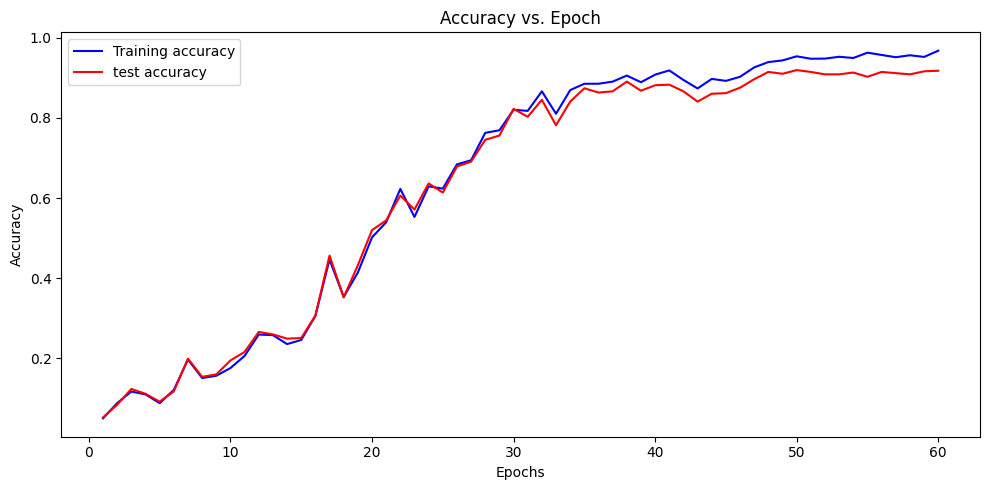

In [3]:
history = tabnet_model.history
print(history)

# Extract and plot values
train_losses = history['loss']
train_accuracies = history['train_accuracy']
valid_accuracies = history['test_accuracy']

epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs, train_accuracies, 'b-', label='Training accuracy')
plt.plot(epochs, valid_accuracies, 'r-', label='test accuracy')
plt.title('Accuracy vs. Epoch')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.savefig('tabnet.png',transparent=True)  # Save the plot as an image file
plt.show()


{'loss': [2.4940330266952513, 0.835152518749237, 0.49794442355632784, 0.4092235594987869, 0.3233246773481369, 0.29879420846700666, 0.25359427332878115, 0.2576218664646149, 0.25630253106355666, 0.24433443695306778, 0.21502670794725418, 0.2289739653468132, 0.24182915687561035, 0.18750615492463113, 0.19451119750738144, 0.20655401796102524, 0.24238881468772888, 0.21053722575306894, 0.19418446570634842, 0.18908738642930983, 0.2029578998684883, 0.17067915722727775, 0.1861653208732605, 0.19513370394706725, 0.15865466594696045, 0.16456542015075684, 0.15573953688144684, 0.1596136912703514, 0.1514604516327381, 0.17037272825837135, 0.1659439355134964, 0.17400302290916442, 0.21857489198446273, 0.1827044390141964, 0.154985523596406, 0.14643339291214943, 0.16785422191023827, 0.17371828109025955, 0.16173552945256234, 0.15091635957360267, 0.16520815640687941, 0.18329865857958794, 0.22158602327108384, 0.19590755850076674, 0.23109873831272126, 0.17833204790949822, 0.1614436127245426, 0.1802838586270809,

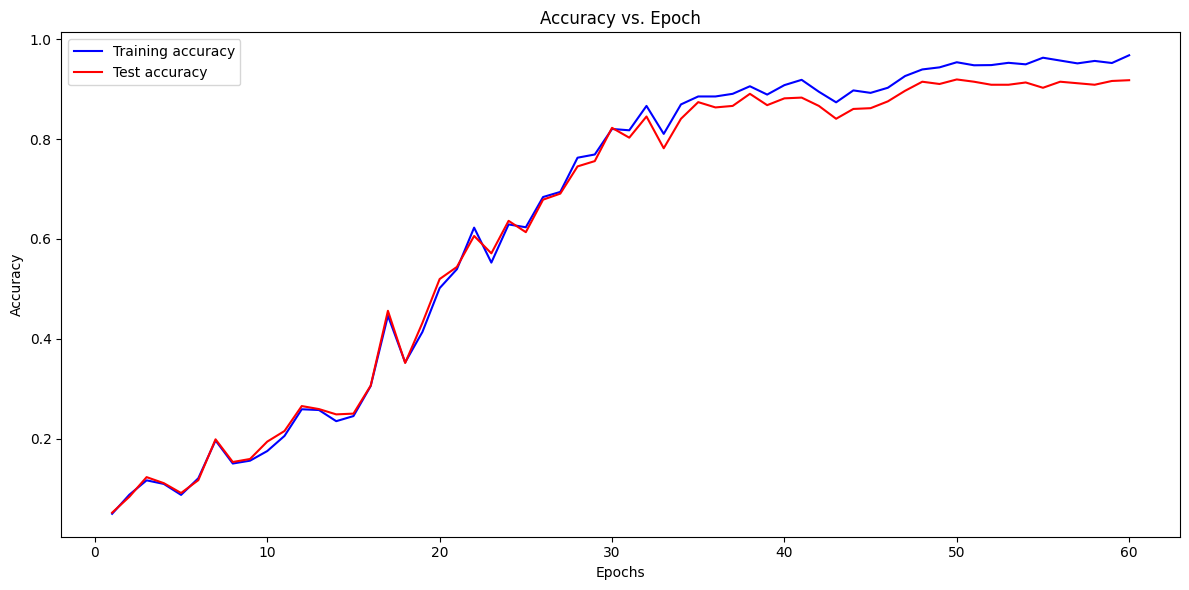

In [4]:
history = tabnet_model.history
print(history)

# Extract and plot values
train_losses = history['loss']
train_accuracies = history['train_accuracy']
valid_accuracies = history['test_accuracy']

epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(12, 6))  # Increased figure size
plt.plot(epochs, train_accuracies, 'b-', label='Training accuracy')
plt.plot(epochs, valid_accuracies, 'r-', label='Test accuracy')
plt.title('Accuracy vs. Epoch')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.savefig('tabnet.png', dpi=300, transparent=True)  # High-resolution image
plt.show()


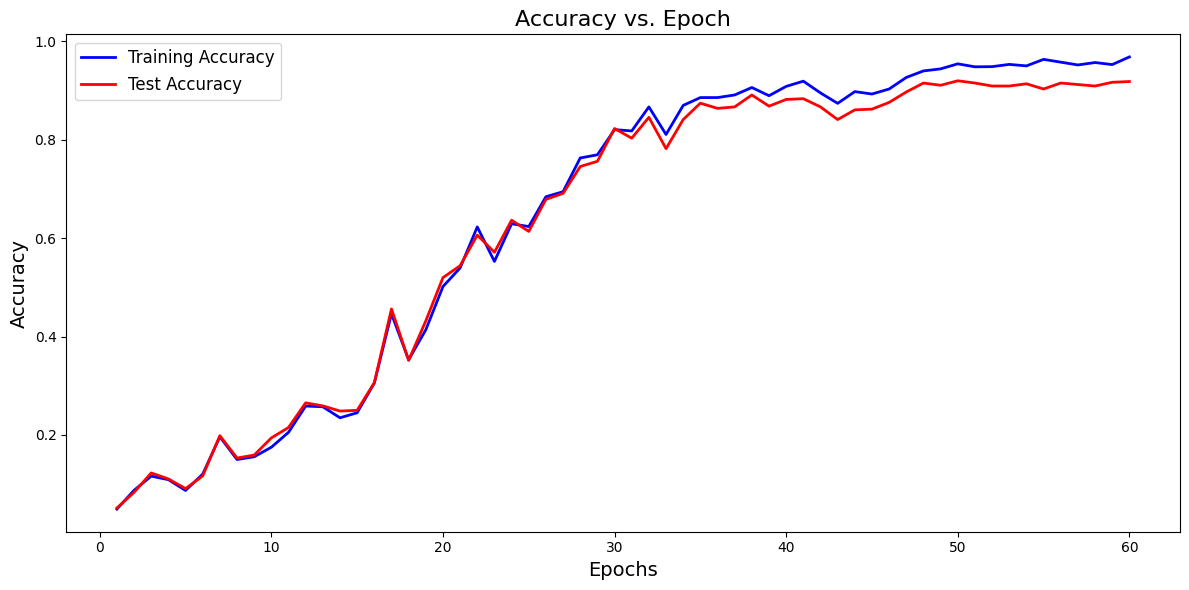

In [5]:
history = tabnet_model.history

train_losses = history['loss']
train_accuracies = history['train_accuracy']
valid_accuracies = history['test_accuracy']

epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(12, 6))
plt.plot(epochs, train_accuracies, 'b-', label='Training Accuracy', linewidth=2)
plt.plot(epochs, valid_accuracies, 'r-', label='Test Accuracy', linewidth=2)

plt.title('Accuracy vs. Epoch', fontsize=16)
plt.xlabel('Epochs', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)
plt.legend(fontsize=12)

plt.tight_layout()
plt.savefig('tabnet300dpi.png', dpi=300, transparent=True)
plt.show()


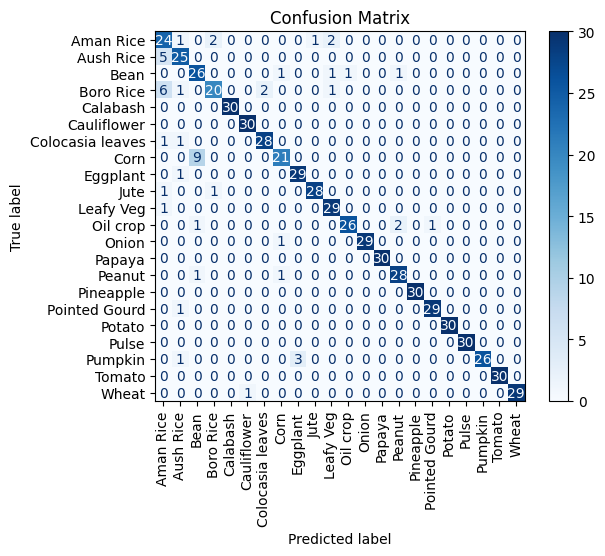

In [6]:
from sklearn.metrics import ConfusionMatrixDisplay

# Plot the confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_test_pred,
    display_labels=label_encoder.classes_,
    cmap='Blues',
    xticks_rotation='vertical'
)
plt.title("Confusion Matrix")
plt.savefig('tabnetConfusiondpi300.png',dpi=300,transparent=True)  # Save the plot as an image file

plt.show()